Bank Deposit Subscription Prediction

Final Machine Learning Project

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.preprocessing import StandardScaler

print("Libraries loaded")

Libraries loaded


Data Loading

In this section, the dataset is loaded and initial observations are examined.

In [ ]:
df = pd.read_csv("bank-additional-full.csv", sep=";")

df.head()

,age,job,marital,education,default,housing,loan,contact,month,day_of_week,...,campaign,pdays,previous,poutcome,emp.var.rate,cons.price.idx,cons.conf.idx,euribor3m,nr.employed,y
0,56,housemaid,married,basic.4y,no,no,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
1,57,services,married,high.school,unknown,no,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
2,37,services,married,high.school,no,yes,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
3,40,admin.,married,basic.6y,no,no,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
4,56,services,married,high.school,no,no,yes,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no


Dataset Overview

The structure, dimensions and data types of the dataset are examined.

In [ ]:
print(df.shape)

df.info()

(41188, 21)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 41188 entries, 0 to 41187
Data columns (total 21 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   age             41188 non-null  int64  
 1   job             41188 non-null  object 
 2   marital         41188 non-null  object 
 3   education       41188 non-null  object 
 4   default         41188 non-null  object 
 5   housing         41188 non-null  object 
 6   loan            41188 non-null  object 
 7   contact         41188 non-null  object 
 8   month           41188 non-null  object 
 9   day_of_week     41188 non-null  object 
 10  duration        41188 non-null  int64  
 11  campaign        41188 non-null  int64  
 12  pdays           41188 non-null  int64  
 13  previous        41188 non-null  int64  
 14  poutcome        41188 non-null  object 
 15  emp.var.rate    41188 non-null  float64
 16  cons.price.idx  41188 non-null  float64
 17  cons.conf.idx   411

In [4]:
df.isnull().sum()

age               0
job               0
marital           0
education         0
default           0
housing           0
loan              0
contact           0
month             0
day_of_week       0
duration          0
campaign          0
pdays             0
previous          0
poutcome          0
emp.var.rate      0
cons.price.idx    0
cons.conf.idx     0
euribor3m         0
nr.employed       0
y                 0
dtype: int64

In [5]:
df["y"].value_counts()

y
no     36548
yes     4640
Name: count, dtype: int64

Exploratory Data Analysis (EDA)

EDA is performed to understand customer characteristics, target distribution and important patterns within the dataset.

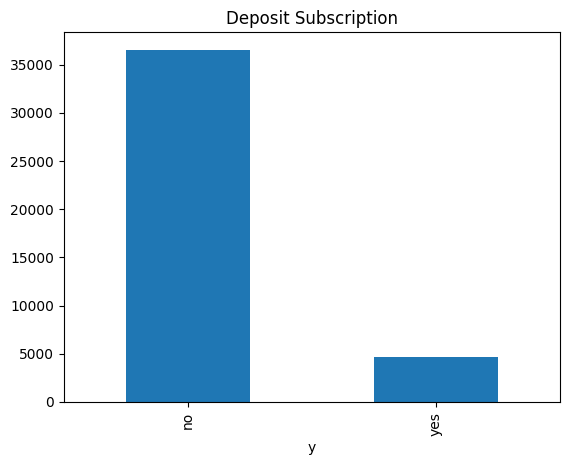

In [6]:
df["y"].value_counts().plot(kind="bar")

plt.title("Deposit Subscription")
plt.show()

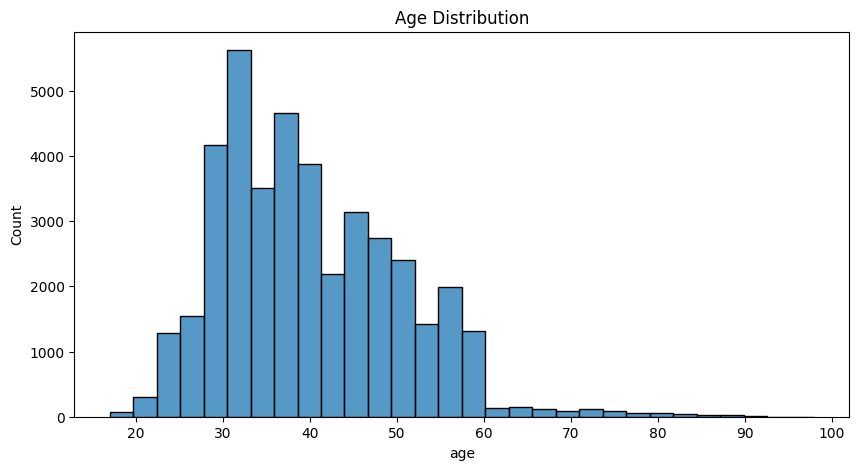

In [7]:
plt.figure(figsize=(10,5))

sns.histplot(df["age"], bins=30)

plt.title("Age Distribution")
plt.show()

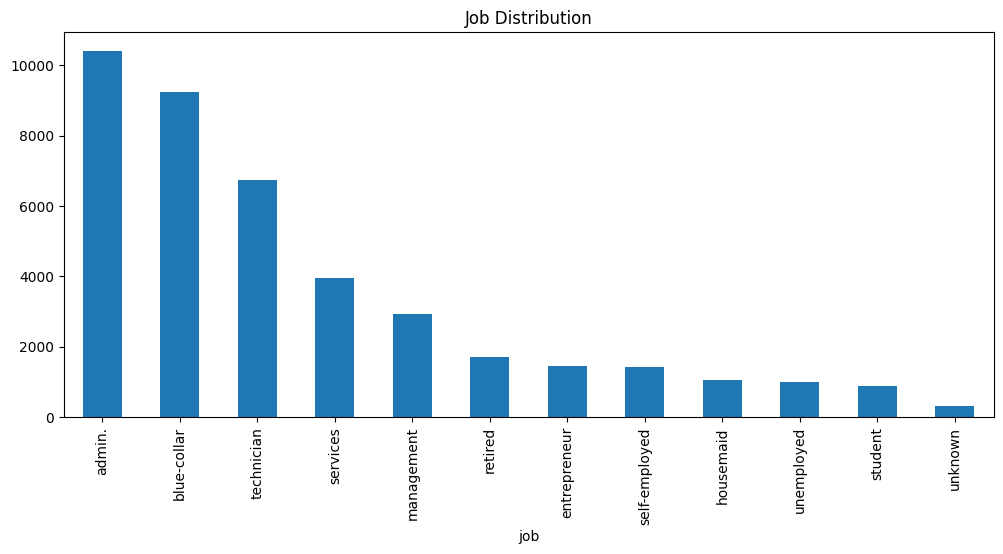

In [8]:
plt.figure(figsize=(12,5))

df["job"].value_counts().plot(kind="bar")

plt.title("Job Distribution")

plt.show()

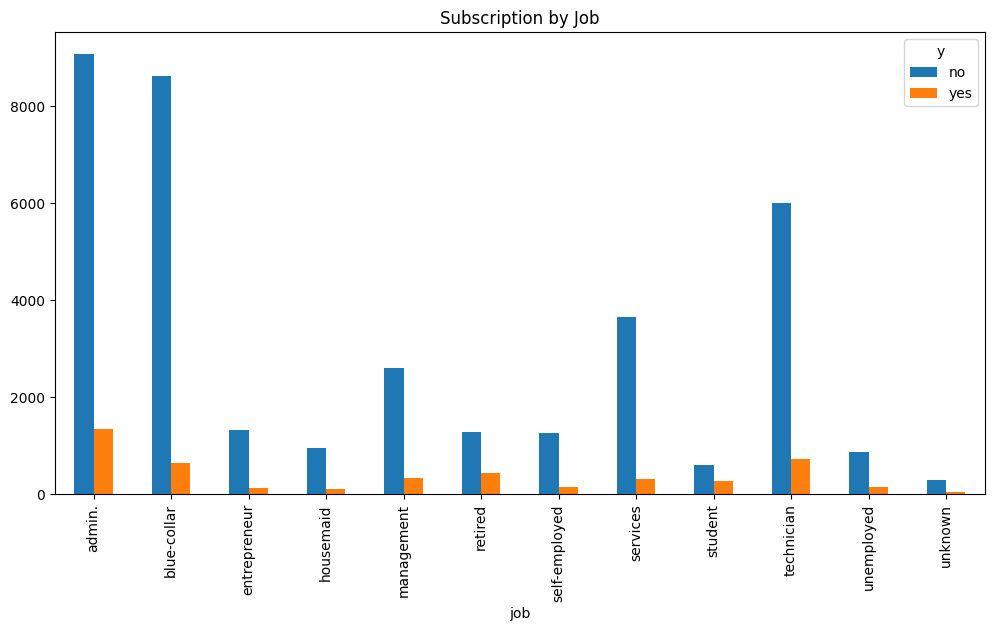

In [9]:
job_sub = pd.crosstab(df["job"], df["y"])

job_sub.plot(kind="bar", figsize=(12,6))

plt.title("Subscription by Job")

plt.show()

Data Preprocessing

The dataset is prepared for machine learning by encoding categorical variables, defining features and target variables, and creating training and testing datasets.

In [30]:
data = df.copy()

X = data.drop("y", axis=1)

y = data["y"]

In [12]:
le = LabelEncoder()

y = le.fit_transform(y)

In [13]:
X = pd.get_dummies(X)

In [14]:
print(X.shape)

(41188, 63)


In [15]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

In [16]:
scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)

X_test = scaler.transform(X_test)

Logistic Regression Model

A Logistic Regression model is trained and evaluated as the baseline machine learning approach.

In [17]:
from sklearn.linear_model import LogisticRegression

model_lr = LogisticRegression(max_iter=1000)

model_lr.fit(X_train, y_train)

,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,None
,random_state,None
,solver,'lbfgs'
,max_iter,1000
,multi_class,'deprecated'


In [18]:
y_pred_lr = model_lr.predict(X_test)

In [19]:
from sklearn.metrics import classification_report

print(classification_report(y_test, y_pred_lr))

              precision    recall  f1-score   support

           0       0.93      0.97      0.95      7303
           1       0.67      0.43      0.53       935

    accuracy                           0.91      8238
   macro avg       0.80      0.70      0.74      8238
weighted avg       0.90      0.91      0.90      8238



Random Forest Model

A Random Forest classifier is trained and evaluated to compare its performance with Logistic Regression.

In [20]:
from sklearn.ensemble import RandomForestClassifier

model_rf = RandomForestClassifier(
    n_estimators=200,
    random_state=42
)

model_rf.fit(X_train, y_train)

,n_estimators,200
,criterion,'gini'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,'sqrt'
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


In [21]:
y_pred_rf = model_rf.predict(X_test)

In [22]:
print(classification_report(y_test, y_pred_rf))

              precision    recall  f1-score   support

           0       0.93      0.97      0.95      7303
           1       0.65      0.46      0.54       935

    accuracy                           0.91      8238
   macro avg       0.79      0.72      0.75      8238
weighted avg       0.90      0.91      0.90      8238



In [23]:
from sklearn.metrics import accuracy_score

lr_acc = accuracy_score(y_test, y_pred_lr)

rf_acc = accuracy_score(y_test, y_pred_rf)

print("Logistic Regression:", lr_acc)

print("Random Forest:", rf_acc)

Logistic Regression: 0.9112648701141054
Random Forest: 0.911143481427531


Model Evaluation

The performance of both machine learning models is evaluated using Accuracy, Precision, Recall, F1-score and ROC-AUC.

In [24]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

print("LOGISTIC REGRESSION")
print("Accuracy:", accuracy_score(y_test, y_pred_lr))
print("Precision:", precision_score(y_test, y_pred_lr))
print("Recall:", recall_score(y_test, y_pred_lr))
print("F1:", f1_score(y_test, y_pred_lr))

print("\nRANDOM FOREST")
print("Accuracy:", accuracy_score(y_test, y_pred_rf))
print("Precision:", precision_score(y_test, y_pred_rf))
print("Recall:", recall_score(y_test, y_pred_rf))
print("F1:", f1_score(y_test, y_pred_rf))

LOGISTIC REGRESSION
Accuracy: 0.9112648701141054
Precision: 0.6683168316831684
Recall: 0.43315508021390375
F1: 0.5256327060350422

RANDOM FOREST
Accuracy: 0.911143481427531
Precision: 0.6530920060331825
Recall: 0.46310160427807484
F1: 0.541927409261577


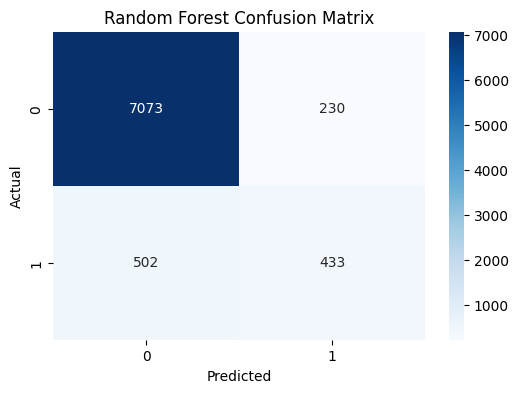

In [25]:
from sklearn.metrics import confusion_matrix
import seaborn as sns

cm = confusion_matrix(y_test, y_pred_rf)

plt.figure(figsize=(6,4))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")

plt.title("Random Forest Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.show()

Feature Importance Analysis

The importance of individual features is examined using the Random Forest model.

In [26]:
feature_importance = pd.DataFrame({
    "Feature": X.columns,
    "Importance": model_rf.feature_importances_
})

feature_importance = feature_importance.sort_values(
    by="Importance",
    ascending=False
)

print(feature_importance.head(15))

                        Feature  Importance
1                      duration    0.275251
8                     euribor3m    0.090593
0                           age    0.079140
9                   nr.employed    0.050887
2                      campaign    0.039319
3                         pdays    0.031033
7                 cons.conf.idx    0.027491
5                  emp.var.rate    0.025697
6                cons.price.idx    0.022098
62             poutcome_success    0.017885
39                  housing_yes    0.013546
37                   housing_no    0.013469
4                      previous    0.012138
32  education_university.degree    0.012092
10                   job_admin.    0.011932


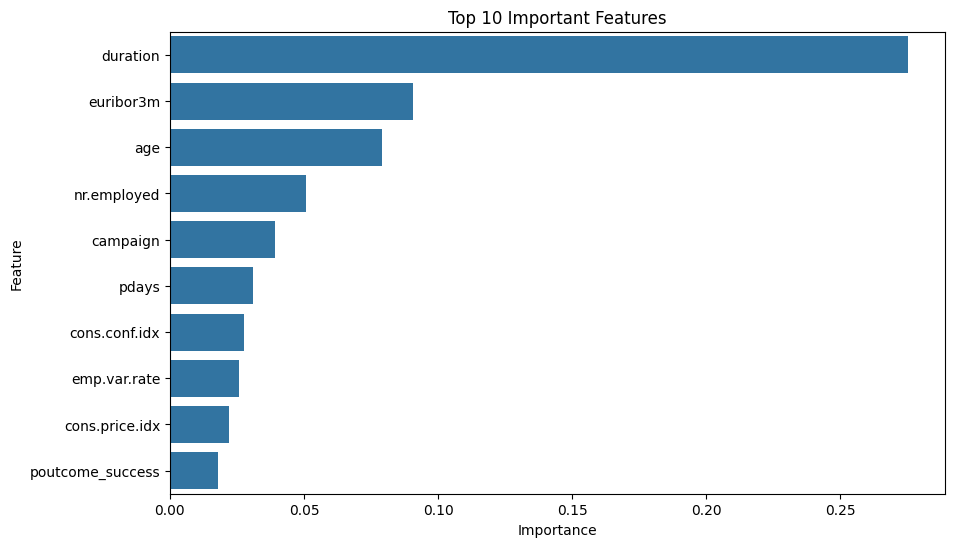

In [27]:
plt.figure(figsize=(10,6))

sns.barplot(
    data=feature_importance.head(10),
    x="Importance",
    y="Feature"
)

plt.title("Top 10 Important Features")

plt.show()

In [28]:
from sklearn.metrics import roc_auc_score

lr_auc = roc_auc_score(y_test, model_lr.predict_proba(X_test)[:,1])

rf_auc = roc_auc_score(y_test, model_rf.predict_proba(X_test)[:,1])

print("Logistic Regression ROC-AUC:", lr_auc)

print("Random Forest ROC-AUC:", rf_auc)

Logistic Regression ROC-AUC: 0.9348921877391241
Random Forest ROC-AUC: 0.9404763700508398


In [29]:
feature_importance = pd.DataFrame({
    "Feature": X.columns,
    "Importance": model_rf.feature_importances_
})

feature_importance = feature_importance.sort_values(
    by="Importance",
    ascending=False
)

print(feature_importance.head(10))

             Feature  Importance
1           duration    0.275251
8          euribor3m    0.090593
0                age    0.079140
9        nr.employed    0.050887
2           campaign    0.039319
3              pdays    0.031033
7      cons.conf.idx    0.027491
5       emp.var.rate    0.025697
6     cons.price.idx    0.022098
62  poutcome_success    0.017885
